In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('data/salary_data_cleaned.csv')
df.head(5)

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,...,avg_salary,company_txt,job_state,same_state,age,python_yn,R_yn,spark,aws,excel
0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,...,72.0,Tecolote Research\n,NM,0,47,1,0,0,0,1
1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,...,87.5,University of Maryland Medical System\n,MD,0,36,1,0,0,0,0
2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,...,85.0,KnowBe4\n,FL,1,10,1,0,1,0,1
3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,Government,...,76.5,PNNL\n,WA,1,55,1,0,0,0,0
4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,...,114.5,Affinity Solutions\n,NY,1,22,1,0,0,0,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Job Title          742 non-null    str    
 1   Salary Estimate    742 non-null    str    
 2   Job Description    742 non-null    str    
 3   Rating             742 non-null    float64
 4   Company Name       742 non-null    str    
 5   Location           742 non-null    str    
 6   Headquarters       742 non-null    str    
 7   Size               742 non-null    str    
 8   Founded            742 non-null    int64  
 9   Type of ownership  742 non-null    str    
 10  Industry           742 non-null    str    
 11  Sector             742 non-null    str    
 12  Revenue            742 non-null    str    
 13  Competitors        742 non-null    str    
 14  hourly             742 non-null    int64  
 15  employer_provided  742 non-null    int64  
 16  min_salary         742 non-null    in

In [4]:
simple_data = df[['Size', 'Rating', 'Revenue', 'min_salary', 'max_salary', 'avg_salary']]

In [5]:
simple_data.head(5)

,Size,Rating,Revenue,min_salary,max_salary,avg_salary
0,501 to 1000 employees,3.8,$50 to $100 million (USD),53,91,72.0
1,10000+ employees,3.4,$2 to $5 billion (USD),63,112,87.5
2,501 to 1000 employees,4.8,$100 to $500 million (USD),80,90,85.0
3,1001 to 5000 employees,3.8,$500 million to $1 billion (USD),56,97,76.5
4,51 to 200 employees,2.9,Unknown / Non-Applicable,86,143,114.5


In [6]:
df['Size'].value_counts()

Size
1001 to 5000 employees     150
501 to 1000 employees      134
10000+ employees           130
201 to 500 employees       117
51 to 200 employees         94
5001 to 10000 employees     76
1 to 50 employees           31
Unknown                      9
-1                           1
Name: count, dtype: int64

In [7]:
df['Revenue'].value_counts()

Revenue
Unknown / Non-Applicable            203
$10+ billion (USD)                  124
$100 to $500 million (USD)           91
$1 to $2 billion (USD)               60
$500 million to $1 billion (USD)     57
$50 to $100 million (USD)            46
$25 to $50 million (USD)             40
$2 to $5 billion (USD)               39
$10 to $25 million (USD)             32
$5 to $10 billion (USD)              19
$5 to $10 million (USD)              18
$1 to $5 million (USD)                8
Less than $1 million (USD)            4
-1                                    1
Name: count, dtype: int64

In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
encoder = LabelEncoder()

In [10]:
simple_data['Size'] = encoder.fit_transform(simple_data['Size'])

In [11]:
simple_data.head()

,Size,Rating,Revenue,min_salary,max_salary,avg_salary
0,6,3.8,$50 to $100 million (USD),53,91,72.0
1,2,3.4,$2 to $5 billion (USD),63,112,87.5
2,6,4.8,$100 to $500 million (USD),80,90,85.0
3,3,3.8,$500 million to $1 billion (USD),56,97,76.5
4,7,2.9,Unknown / Non-Applicable,86,143,114.5


In [12]:
simple_data['Revenue'] = encoder.fit_transform(simple_data['Revenue'])

In [13]:
simple_data.head(5)

,Size,Rating,Revenue,min_salary,max_salary,avg_salary
0,6,3.8,9,53,91,72.0
1,2,3.4,5,63,112,87.5
2,6,4.8,4,80,90,85.0
3,3,3.8,10,56,97,76.5
4,7,2.9,13,86,143,114.5


In [14]:
simple_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Size        742 non-null    int64  
 1   Rating      742 non-null    float64
 2   Revenue     742 non-null    int64  
 3   min_salary  742 non-null    int64  
 4   max_salary  742 non-null    int64  
 5   avg_salary  742 non-null    float64
dtypes: float64(2), int64(4)
memory usage: 34.9 KB


In [15]:
X_train = simple_data.drop(columns='avg_salary')

In [16]:
Y_train = simple_data['avg_salary']

In [17]:
X_train.head(5)

,Size,Rating,Revenue,min_salary,max_salary
0,6,3.8,9,53,91
1,2,3.4,5,63,112
2,6,4.8,4,80,90
3,3,3.8,10,56,97
4,7,2.9,13,86,143


In [18]:
Y_train

0       72.0
1       87.5
2       85.0
3       76.5
4      114.5
       ...  
737     84.5
738    102.5
739     73.5
740    127.5
741     93.5
Name: avg_salary, Length: 742, dtype: float64

In [19]:
from sklearn.model_selection import train_test_split
X_train, x_test, Y_train, y_test = train_test_split(X_train, Y_train, test_size=0.2, random_state=42)

In [20]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 593 entries, 481 to 102
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Size        593 non-null    int64  
 1   Rating      593 non-null    float64
 2   Revenue     593 non-null    int64  
 3   min_salary  593 non-null    int64  
 4   max_salary  593 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 27.8 KB


In [21]:
Y_train.info()

<class 'pandas.Series'>
Index: 593 entries, 481 to 102
Series name: avg_salary
Non-Null Count  Dtype  
--------------  -----  
593 non-null    float64
dtypes: float64(1)
memory usage: 9.3 KB


In [22]:
x_test.info()

<class 'pandas.DataFrame'>
Index: 149 entries, 120 to 70
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Size        149 non-null    int64  
 1   Rating      149 non-null    float64
 2   Revenue     149 non-null    int64  
 3   min_salary  149 non-null    int64  
 4   max_salary  149 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 7.0 KB


In [23]:
y_test.info()

<class 'pandas.Series'>
Index: 149 entries, 120 to 70
Series name: avg_salary
Non-Null Count  Dtype  
--------------  -----  
149 non-null    float64
dtypes: float64(1)
memory usage: 2.3 KB


In [26]:
from linearregression2 import LinearRegressionGD
model = LinearRegressionGD()

model.fit(X_train_scaled, Y_train)

[[-1.73855457 -0.05197215 -1.12832113 -0.83881516 -0.89371101]
 [-1.20103483  0.34484525 -0.90469331  0.45506334  0.7749759 ]
 [-1.20103483  0.34484525 -0.90469331  0.89687551  0.99168849]
 [-1.20103483  0.08030032 -0.90469331  0.77064347  1.20840108]
 [-0.66351509 -0.31651709 -0.68106549 -0.08142286 -0.07020318]
 [-0.66351509  0.87393512  1.33158486 -0.64946708 -0.46028584]
 [-1.20103483  0.47711772 -0.90469331 -0.33388696 -0.46028584]
 [ 0.94904413  0.47711772  0.66070141  0.01325117 -0.04853192]
 [-0.66351509  0.21257279  0.66070141 -0.428561   -0.54697087]
 [-1.73855457 -1.5069693   1.33158486  1.18089762  1.07837353]]
[[ 66. ]
 [125. ]
 [137. ]
 [140. ]
 [ 97. ]
 [ 79. ]
 [ 84. ]
 [ 99. ]
 [ 80.5]
 [143.5]]


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(x_test)

In [27]:
y_pred = model.predict(X_test_scaled)

In [28]:
from sklearn.metrics import r2_score
accuracy = r2_score(y_pred, y_test)

In [29]:
print(accuracy)

0.9996833201537496


In [30]:
model.cost_history

[np.float64(5727.654510961213),
 np.float64(5599.9796114140745),
 np.float64(5475.37384804635),
 np.float64(5353.755775769926),
 np.float64(5235.046355436181),
 np.float64(5119.168875691136),
 np.float64(5006.048877552382),
 np.float64(4895.614081608657),
 np.float64(4787.7943177466395),
 np.float64(4682.521457313074),
 np.float64(4579.729347623831),
 np.float64(4479.353748734738),
 np.float64(4381.332272392244),
 np.float64(4285.604323084992),
 np.float64(4192.111041120377),
 np.float64(4100.795247652894),
 np.float64(4011.6013915939334),
 np.float64(3924.475498335164),
 np.float64(3839.3651202202805),
 np.float64(3756.2192887022206),
 np.float64(3674.988468125361),
 np.float64(3595.624511074408),
 np.float64(3518.08061523386),
 np.float64(3442.3112817040187),
 np.float64(3368.272274721493),
 np.float64(3295.9205827341025),
 np.float64(3225.214380781894),
 np.float64(3156.112994137817),
 np.float64(3088.576863163271),
 np.float64(3022.5675093354143),
 np.float64(2958.047502404724),
 n

In [31]:
from linearregression1 import LinearRegressionFromScratch
model1 = LinearRegressionFromScratch()

model1.fit(X_train_scaled, Y_train)

In [32]:
pred1 = model1.predict(X_test_scaled)

In [33]:
accuracy = r2_score(pred1, y_test)

In [34]:
accuracy

1.0

In [35]:
from sklearn.linear_model import LinearRegression
model2 = LinearRegression()

model2.fit(X_train_scaled, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0. ,-0. , 0. ,15.84,23.07]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,99.91
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[33.97,26.17,24.71,21.98, 5.71]"


In [36]:
y_pred2 = model2.predict(X_test_scaled)

In [37]:
accuracy = r2_score(y_pred2, y_test)

In [38]:
accuracy

1.0

In [39]:
first = [model2.coef_, model2.intercept_]
second = [model1.coef_, model1.intercept_]
print(first)
print(second)

[array([ 4.30057218e-15, -1.06581410e-14,  6.66133815e-15,  1.58438369e+01,
        2.30720332e+01]), np.float64(99.9097807757167)]
[array([7.92877049e-16, 1.55627464e-14, 2.24646690e-15, 1.58438369e+01,
       2.30720332e+01]), np.float64(99.90978077571668)]


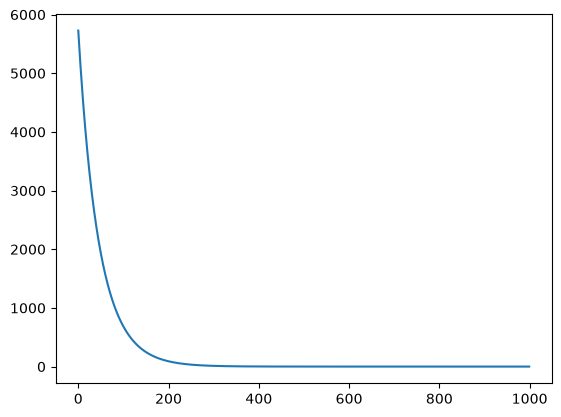

In [ ]:
import matplotlib.pyplot as plt
plt.plot(model.cost_history)

In [43]:
pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 685.6 kB/s eta 0:00:00a 0:00:01
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.1/130.1 kB 1.6 MB/s eta 0:00:00a 0:00:01
  Using cached pillow-12.3.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 1.7 MB/s eta 0:00:0000:0100:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.2/383.2 kB 1.7 MB/s eta 0:00:0000:0100:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 2.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 2.0 MB/s eta 0:00:0000:0100:01
Using cached pillow-12.3.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (6.9 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 1.7 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packa